# YOLOv8 Model Comparison: Original vs Pruned

This notebook compares the original YOLOv8 ONNX model with its pruned version in terms of:
1. **Model Size** (MB)
2. **Inference Latency** (Latency benchmarking on CPU)
3. **Accuracy** (mAP50 and mAP50-95 using the validation set)

In [1]:
import os
import time
import numpy as np
import onnxruntime as ort
import torch
from pathlib import Path
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# Paths to the models
ORIGINAL_MODEL_PATH = Path('models/baseline/yolov8/train/weights/best.onnx')
PRUNED_MODEL_PATH = Path('models/optimised/yolov8/prune/pruned.onnx')
DATASET_YAML = Path('data/camel/dataset.yaml')

# Determine device
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']

print(f"Using device: {DEVICE}")
print(f"ONNX Runtime Providers: {PROVIDERS}")

def get_model_size(path):
    return os.path.getsize(path) / (1024 * 1024)  # Convert to MB


Using device: 0
ONNX Runtime Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']


## 1. Model size comparison

In [2]:
size_orig = get_model_size(ORIGINAL_MODEL_PATH)
size_pruned = get_model_size(PRUNED_MODEL_PATH)

print(f"Original Model Size: {size_orig:.2f} MB")
print(f"Pruned Model Size:   {size_pruned:.2f} MB")
print(f"Reduction:           {(1 - size_pruned/size_orig)*100:.1f}%")

Original Model Size: 166.52 MB
Pruned Model Size:   131.76 MB
Reduction:           20.9%


## 2. Latency Benchmarking (CPU)

We use a dummy input of shape [1, 3, 640, 640] to measure raw inference time.

In [3]:
def benchmark_latency(model_path, iterations=100, warmup=20):
    # Use the globally defined PROVIDERS
    session = ort.InferenceSession(str(model_path), providers=PROVIDERS)
    input_name = session.get_inputs()[0].name
    input_shape = session.get_inputs()[0].shape
    
    # Handle dynamic axes if any
    fixed_shape = [dim if isinstance(dim, int) else 352 for dim in input_shape]
    if fixed_shape[0] == -1 or not isinstance(fixed_shape[0], int): fixed_shape[0] = 1
    
    dummy_input = np.random.randn(*fixed_shape).astype(np.float32)
    
    # Warmup
    for _ in range(warmup):
        _ = session.run(None, {input_name: dummy_input})
    
    # Benchmark
    times = []
    for _ in range(iterations):
        start = time.perf_counter()
        _ = session.run(None, {input_name: dummy_input})
        times.append((time.perf_counter() - start) * 1000) # ms
        
    return np.mean(times), np.median(times), np.std(times)

print("Benchmarking original model latency...")
lat_orig_mean, lat_orig_med, _ = benchmark_latency(ORIGINAL_MODEL_PATH)

print("Benchmarking pruned model latency...")
lat_pruned_mean, lat_pruned_med, _ = benchmark_latency(PRUNED_MODEL_PATH)

print(f"Original Latency (Median): {lat_orig_med:.2f} ms")
print(f"Pruned Latency (Median):   {lat_pruned_med:.2f} ms")
print(f"Speedup:                  {lat_orig_med/lat_pruned_med:.2f}x")


Benchmarking original model latency...
Benchmarking pruned model latency...
Original Latency (Median): 156.34 ms
Pruned Latency (Median):   131.67 ms
Speedup:                  1.19x


## 3. Accuracy Evaluation (mAP)

Using Ultralytics `YOLO.val()` to compute metrics on the CAMEL validation set.

In [4]:
def evaluate_accuracy(model_path, data_yaml):
    model = YOLO(str(model_path), task='detect')
    try:
        print(f"Attempting validation on {DEVICE}...")
        results = model.val(data=str(data_yaml), imgsz=352, device=DEVICE, plots=False, verbose=False)
    except Exception as e:
        print(f"Validation on {DEVICE} failed, falling back to CPU. Error: {str(e)[:100]}...")
        results = model.val(data=str(data_yaml), imgsz=352, device='cpu', plots=False, verbose=False)
    
    return results.results_dict['metrics/mAP50(B)'], results.results_dict['metrics/mAP50-95(B)']

print("Evaluating original model accuracy...")
map50_orig, map95_orig = evaluate_accuracy(ORIGINAL_MODEL_PATH, DATASET_YAML)

print("Evaluating pruned model accuracy...")
map50_pruned, map95_pruned = evaluate_accuracy(PRUNED_MODEL_PATH, DATASET_YAML)

print(f"Original mAP50: {map50_orig:.4f}")
print(f"Pruned mAP50:   {map50_pruned:.4f}")


Evaluating original model accuracy...
Attempting validation on 0...
Ultralytics 8.4.7  Python-3.13.5 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
Loading models\baseline\yolov8\train\weights\best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CUDAExecutionProvider
Setting batch=1 input of shape (1, 3, 352, 352)
val: Fast image access  (ping: 0.10.0 ms, read: 1.50.5 MB/s, size: 9.4 KB)
val: Scanning C:\Users\gerth\Documents\Engineering\optimising-infrared-object-detection\data\camel\labels\val.cache... 4286 images, 1724 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4286/4286 817.1Mit/s 0.0s
Validation on 0 failed, falling back to CPU. Error: Error when binding input: There's no data transfer registered for copying tensors from Device:[Devic...
Ultralytics 8.4.7  Python-3.13.5 torch-2.9.1+cu130 CPU (AMD Ryzen 5 3600 6-Core Processor)
Loading models\baseline\yolov8\train\weights\best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecuti

## 4. Summary Table

,Metric,Original,Pruned,Delta (%)
0,Size (MB),166.518056,131.758056,-20.874613
1,Latency (Median ms),156.343450,131.671650,-15.780514
2,mAP50,0.901121,0.000000,-100.000000
3,mAP50-95,0.827771,0.000000,-100.000000


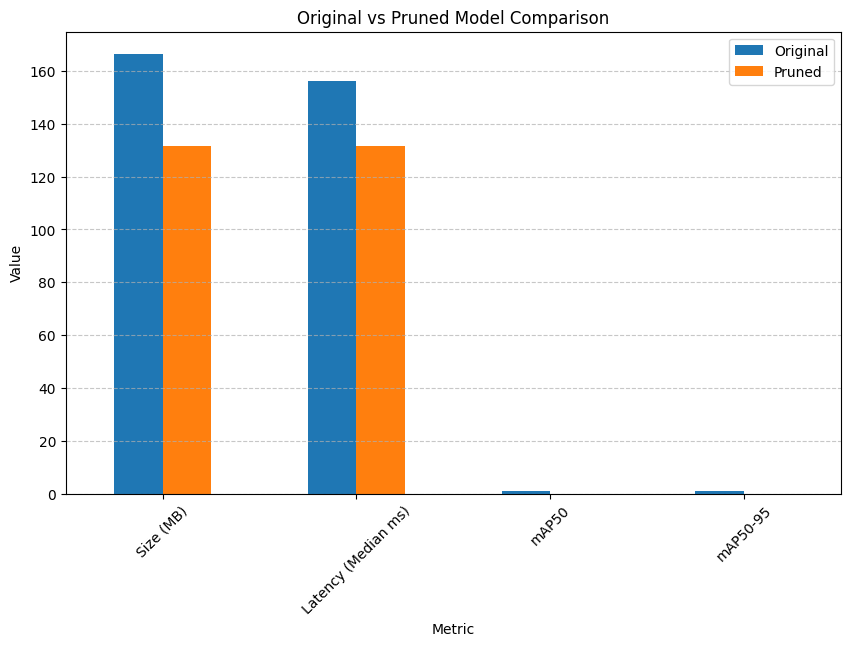

In [5]:
data = {
    'Metric': ['Size (MB)', 'Latency (Median ms)', 'mAP50', 'mAP50-95'],
    'Original': [size_orig, lat_orig_med, map50_orig, map95_orig],
    'Pruned': [size_pruned, lat_pruned_med, map50_pruned, map95_pruned]
}

df = pd.DataFrame(data)
df['Delta (%)'] = ((df['Pruned'] / df['Original']) - 1) * 100
display(df)

# Visualize
df.set_index('Metric')[['Original', 'Pruned']].plot(kind='bar', figsize=(10, 6))
plt.title("Original vs Pruned Model Comparison")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()